In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, KFold

In [3]:
DATA = Path('datasets')

In [4]:
concrete_data = pd.read_csv(DATA / "concrete_data.csv")

In [6]:
concrete_data.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [7]:
concrete_data.shape

(1030, 9)

In [8]:
concrete_data.describe()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


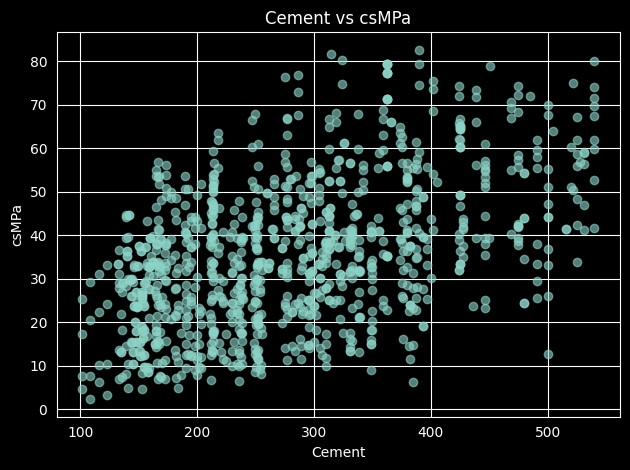

In [10]:
fig, ax = plt.subplots()

ax.scatter(
    concrete_data['cement'],
    concrete_data['csMPa'],
    alpha=0.6,
)

ax.set_title('Cement vs csMPa')
ax.set_xlabel('Cement')
ax.set_ylabel('csMPa')

plt.tight_layout()
plt.show()

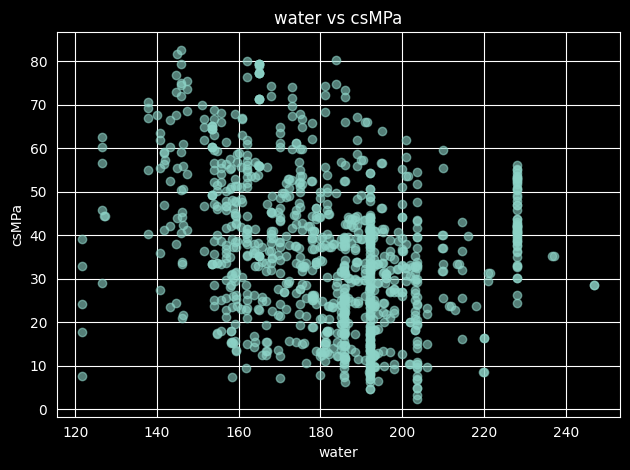

In [11]:
fig, ax = plt.subplots()

ax.scatter(
    concrete_data['water'],
    concrete_data['csMPa'],
    alpha=0.6,
)

ax.set_title('water vs csMPa')
ax.set_xlabel('water')
ax.set_ylabel('csMPa')

plt.tight_layout()
plt.show()

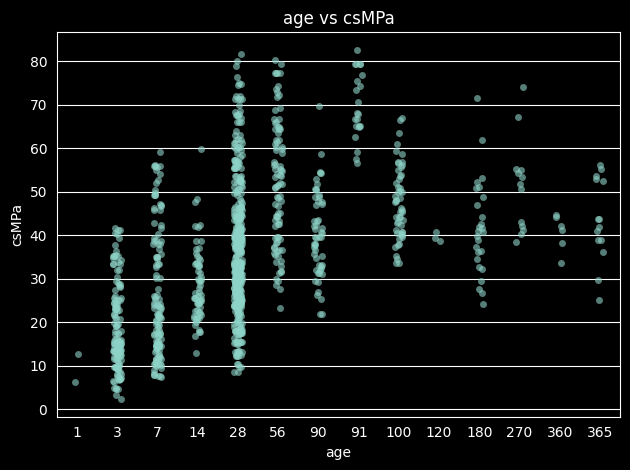

In [15]:
fig, ax = plt.subplots()

sns.stripplot(
    data=concrete_data,
    x='age',
    y='csMPa',
    alpha=0.6,
    ax=ax
)

ax.set_title('age vs csMPa')
ax.set_xlabel('age')
ax.set_ylabel('csMPa')

plt.tight_layout()
plt.show()

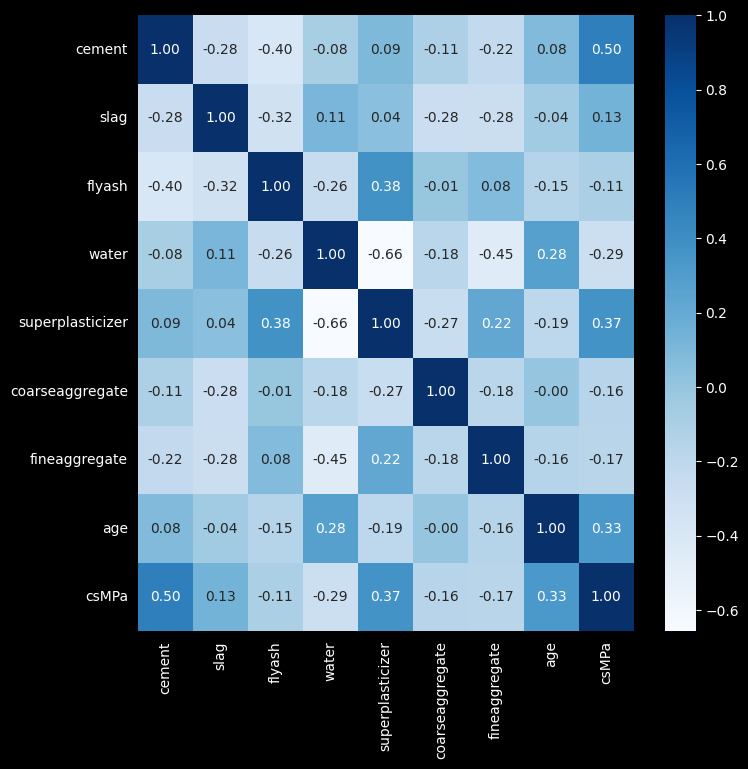

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(concrete_data.corr(), annot=True, ax=ax, fmt='.2f', cmap='Blues')

plt.show()

In [18]:
X = concrete_data.drop(columns='csMPa')
y = concrete_data['csMPa']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [30]:
bag_reg = BaggingRegressor(
    DecisionTreeRegressor(),
    n_estimators=500,
    bootstrap=False, # pasting (without replacements)
    max_samples=1.0,
    n_jobs=-1,
)

In [25]:
bag_reg.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeRegressor()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",1.0
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",False
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [26]:
y_pred = bag_reg.predict(X_test)

In [27]:
df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
})

df.sample(10)

,Actual,Predicted
700,6.88,4.80890
192,27.66,27.66816
244,19.93,12.94896
369,15.34,12.92440
386,56.83,59.07504
320,28.68,42.13074
768,39.00,40.60760
1019,35.23,35.23000
345,33.73,33.70000
280,24.43,29.93000


In [31]:
r2_score(y_test, y_pred)

# model explains 85% target variability (y).
# 85 % variations concrete (MPa) concrete (MPa) the input characteristics are explained.
# 15 % stays not explained (noise, empty variables)

0.837471505968415

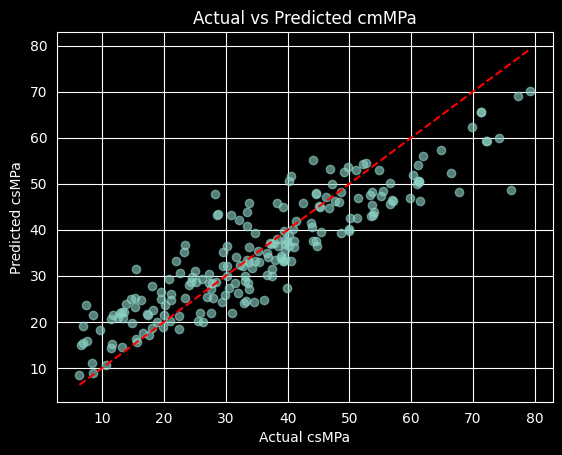

In [44]:
fig, ax = plt.subplots()

ax.scatter(y_test, y_pred, alpha=0.6)
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

ax.set_xlabel('Actual csMPa')
ax.set_ylabel('Predicted csMPa')
ax.set_title('Actual vs Predicted cmMPa')

plt.show()

In [36]:
bag_reg = BaggingRegressor(
    DecisionTreeRegressor(),
    n_estimators=500,
    bootstrap=True, # bagging (without replacements)
    max_samples=0.8,
    n_jobs=-1,
    oob_score=True, # out of bag
)

In [37]:
bag_reg.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeRegressor()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.8
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [38]:
y_pred = bag_reg.predict(X_test)

In [39]:
r2_score(y_test, y_pred)

0.9144992233019748

In [40]:
bag_reg = BaggingRegressor(
    DecisionTreeRegressor(),
    n_estimators=500,
    bootstrap=False,
    max_samples=1.0,
    bootstrap_features=True,
    max_features=0.8,
    n_jobs=-1,
)

In [41]:
bag_reg.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeRegressor()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",1.0
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",0.8
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",False
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",True
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [42]:
y_pred = bag_reg.predict(X_test)

In [43]:
r2_score(y_test, y_pred)

0.7979727853427974

In [58]:
bag_reg = BaggingRegressor(
    DecisionTreeRegressor(),
    n_estimators=500,
    bootstrap=True,
    max_samples=1.0,
)

bag_reg.fit(X_train, y_train)
y_pred = bag_reg.predict(X_test)
r2_score(y_test, y_pred)

0.9168677941822799

In [53]:
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)

param_grid ={
    'n_estimators': [200, 300, 500],
    'max_samples': [0.6, 0.7, 0.8],
    'estimator__max_depth': [6, 8, 10, 12, None],
    'estimator__min_samples_leaf': [1, 3, 5, 10],
    'estimator__min_samples_split': [2, 5, 10, 20]
}


cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=bag_reg,
    param_grid=param_grid,
    scoring='r2',
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

grid.fit(X_train, y_train)

print('Best CV R2:', grid.best_score_)
print('Best params:', grid.best_params_)

best_model = grid.best_estimator_

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
[CV] END estimator__max_depth=6, estimator__min_samples_leaf=1, estimator__min_samples_split=2, max_samples=0.6, n_estimators=200; total time=   1.4s
[CV] END estimator__max_depth=6, estimator__min_samples_leaf=1, estimator__min_samples_split=2, max_samples=0.6, n_estimators=200; total time=   1.3s
[CV] END estimator__max_depth=6, estimator__min_samples_leaf=1, estimator__min_samples_split=2, max_samples=0.6, n_estimators=200; total time=   1.3s
[CV] END estimator__max_depth=6, estimator__min_samples_leaf=1, estimator__min_samples_split=2, max_samples=0.6, n_estimators=200; total time=   1.4s
[CV] END estimator__max_depth=6, estimator__min_samples_leaf=1, estimator__min_samples_split=2, max_samples=0.6, n_estimators=200; total time=   1.5s
[CV] END estimator__max_depth=6, estimator__min_samples_leaf=1, estimator__min_samples_split=2, max_samples=0.6, n_estimators=300; total time=   2.1s
[CV] END estimator__max_depth=6, est

/home/lipov/projects/ensamble_learning/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/lipov/projects/ensamble_learning/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/lipov/projects/ensamble_learning/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/l

[CV] END estimator__max_depth=12, estimator__min_samples_leaf=5, estimator__min_samples_split=10, max_samples=0.6, n_estimators=300; total time=   4.3s
[CV] END estimator__max_depth=12, estimator__min_samples_leaf=5, estimator__min_samples_split=10, max_samples=0.6, n_estimators=300; total time=   3.4s
[CV] END estimator__max_depth=12, estimator__min_samples_leaf=5, estimator__min_samples_split=10, max_samples=0.7, n_estimators=200; total time=   2.3s
[CV] END estimator__max_depth=12, estimator__min_samples_leaf=5, estimator__min_samples_split=10, max_samples=0.7, n_estimators=200; total time=   3.0s
[CV] END estimator__max_depth=12, estimator__min_samples_leaf=5, estimator__min_samples_split=10, max_samples=0.6, n_estimators=500; total time=   6.2s
[CV] END estimator__max_depth=12, estimator__min_samples_leaf=5, estimator__min_samples_split=10, max_samples=0.6, n_estimators=500; total time=   6.2s
[CV] END estimator__max_depth=12, estimator__min_samples_leaf=5, estimator__min_samples_

In [54]:
grid.best_params_

{'estimator__max_depth': 12,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'max_samples': 0.8,
 'n_estimators': 300}

In [55]:
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(
        random_state=42,
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=2
        ),
    bootstrap=True,
    n_jobs=-1,
    max_samples=0.8,
    n_estimators=500,
    random_state=42
)

bag_reg.fit(X_train, y_train)
y_pred = bag_reg.predict(X_test)

r2_score(y_test, y_pred)

0.9145171172470755